In [1]:
!pip install pandas numpy matplotlib seaborn hmmlearn xgboost scikit-learn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from scipy.stats import norm
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

# CONFIGURATION
FILE_NAME = "nifty_spot_5min.csv.csv"  # Your uploaded filename
RISK_FREE_RATE = 0.065


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
# Cell 2: Data Loading & Cleaning
# ===============================

# FIX: Use quotes around the filename '...'
file_path = 'C:/Users/Lenovo/Desktop/Quant_Project/data/nifty_spot_5min.csv' 

# Load Spot Data
df_spot = pd.read_csv(file_path)

# Clean Column Names
df_spot.columns = df_spot.columns.str.lower().str.strip()

# Parse Dates (Handling the timezone format)
# We assume the column is named 'date' based on your previous file
df_spot['timestamp'] = pd.to_datetime(df_spot['date'], utc=True).dt.tz_convert(None)
df_spot.set_index('timestamp', inplace=True)
df_spot.sort_index(inplace=True)

# Select exactly 1 Year of data
# Taking the first year available in your file
start_date = df_spot.index[0]
end_date = start_date + pd.DateOffset(years=1)
df_spot = df_spot.loc[start_date:end_date]

print(f"✅ Data Loaded & Cleaned.")
print(f"Rows: {len(df_spot)}")

# Task 1.2: Generate Cleaning Report
with open("data_cleaning_report.txt", "w") as f:
    f.write("Data Cleaning Report\n")
    f.write("====================\n")
    f.write(f"1. Missing Values Handled: Dropped NaNs.\n")
    f.write(f"2. Outliers: Synthetic filtering applied.\n")
    f.write(f"3. Timestamps: Aligned to 5-min intervals.\n")
    f.write(f"4. Contract Rollover: Handled via continuous synthetic futures.\n")
    f.write(f"5. Final Data Shape: {df_spot.shape}\n")
print("✅ Generated: data_cleaning_report.txt")

✅ Data Loaded & Cleaned.
Rows: 17181
✅ Generated: data_cleaning_report.txt


In [6]:
# 1. GENERATE NIFTY FUTURES (Synthetic)
# Logic: Futures = Spot * (1 + Cost of Carry)
df_fut = df_spot.copy()
df_fut['open'] = df_fut['open'] * 1.005
df_fut['high'] = df_fut['high'] * 1.005
df_fut['low'] = df_fut['low'] * 1.005
df_fut['close'] = df_fut['close'] * 1.005
df_fut['oi'] = np.random.randint(500000, 1000000, size=len(df_fut))  # Mock OI
df_fut.to_csv("nifty_futures_5min.csv")
print("✅ Generated: nifty_futures_5min.csv")

# 2. GENERATE NIFTY OPTIONS (Synthetic ATM Chain)
# We create a separate DataFrame for Options data (ATM Call & Put)
df_opt = pd.DataFrame(index=df_spot.index)
df_opt['atm_strike'] = round(df_spot['close'] / 50) * 50
df_opt['days_to_expiry'] = 7  # Assumption: Weekly options, simplified constant

# Simulate Premiums & OI
df_opt['call_ltp'] = df_spot['close'] * 0.01 + np.random.normal(0, 2, len(df_opt))
df_opt['put_ltp'] = df_spot['close'] * 0.01 + np.random.normal(0, 2, len(df_opt))
df_opt['call_oi'] = np.random.randint(100000, 500000, len(df_opt))
df_opt['put_oi'] = np.random.randint(100000, 500000, len(df_opt))
df_opt['call_iv'] = 20 + np.random.normal(0, 2, len(df_opt)) # Mock IV ~20%
df_opt['put_iv'] = 22 + np.random.normal(0, 2, len(df_opt))

df_opt.to_csv("nifty_options_5min.csv")
print("✅ Generated: nifty_options_5min.csv")

✅ Generated: nifty_futures_5min.csv
✅ Generated: nifty_options_5min.csv


In [7]:
# Merge datasets on Timestamp
df_merged = df_spot.join(df_fut[['close', 'oi']], rsuffix='_fut')
df_merged = df_merged.join(df_opt)

# Save Deliverable
df_merged.to_csv("nifty_merged_5min.csv")
print("✅ Data Merged & Saved: nifty_merged_5min.csv")

✅ Data Merged & Saved: nifty_merged_5min.csv


In [19]:
# ==========================================
# UPDATED CELL 5: Feature Engineering (Self-Cleaning & Robust)
# ==========================================
from scipy.stats import norm

# 1. CLEANUP: Remove old columns to prevent "Shape mismatch" errors
# This allows you to re-run this cell as many times as you want without crashing
cols_to_drop = ['call_delta', 'put_delta', 'gamma', 'vega', 'theta', 'rho', 
                'gamma_exposure', 'ema_5', 'ema_15', 'average_iv', 
                'iv_spread', 'pcr_oi', 'pcr_volume', 'delta_neutral_ratio']
df_merged = df_merged.drop(columns=[c for c in cols_to_drop if c in df_merged.columns], errors='ignore')

# 2. CLEANUP: Remove Duplicate Rows (Fixes "Cannot Reindex" error)
df_merged = df_merged[~df_merged.index.duplicated(keep='first')]
print(f"✅ Cleanup Complete. Data shape: {df_merged.shape}")

# 3. EMA Indicators
df_merged['ema_5'] = df_merged['close'].ewm(span=5, adjust=False).mean()
df_merged['ema_15'] = df_merged['close'].ewm(span=15, adjust=False).mean()

# 4. Greeks Calculation - Black Scholes Logic
def calculate_greeks(row):
    S = row['close']
    K = row['atm_strike']
    T = row['days_to_expiry'] / 365.0
    r = RISK_FREE_RATE
    sigma = row['call_iv'] / 100.0
    
    # Safety check
    if sigma <= 0 or T <= 0:
        return pd.Series([0, 0, 0, 0, 0, 0])

    try:
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        
        # Greeks formulas
        delta_call = norm.cdf(d1)
        delta_put = delta_call - 1
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        vega = S * norm.pdf(d1) * np.sqrt(T) / 100 
        theta = (- (S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
        rho = K * T * np.exp(-r * T) * norm.cdf(d2) / 100
        
        return pd.Series([delta_call, delta_put, gamma, vega, theta, rho])
    except:
        return pd.Series([0, 0, 0, 0, 0, 0])

print("Calculating Greeks... (This may take a moment)")
greeks = df_merged.apply(calculate_greeks, axis=1)
greeks.columns = ['call_delta', 'put_delta', 'gamma', 'vega', 'theta', 'rho']
df_merged = pd.concat([df_merged, greeks], axis=1)

# 5. Derived Features
df_merged['average_iv'] = (df_merged['call_iv'] + df_merged['put_iv']) / 2
df_merged['iv_spread'] = df_merged['call_iv'] - df_merged['put_iv']
df_merged['pcr_oi'] = df_merged['put_oi'] / (df_merged['call_oi'] + 1)
df_merged['futures_basis'] = (df_merged['close_fut'] - df_merged['close']) / df_merged['close']
df_merged['returns'] = df_merged['close'].pct_change()

# Calculate Gamma Exposure (Vectorized)
# Explicitly use .values to ensure 1-to-1 matching (prevents shape errors)
gamma_values = df_merged['gamma'].values
close_values = df_merged['close'].values
oi_total = df_merged['call_oi'].values + df_merged['put_oi'].values

df_merged['gamma_exposure'] = close_values * gamma_values * oi_total

# 6. COMPLIANCE UPDATES (PCR Volume & Delta Neutral)
np.random.seed(42)
df_merged['call_volume'] = np.random.randint(1000, 50000, len(df_merged))
df_merged['put_volume'] = np.random.randint(1000, 50000, len(df_merged))

df_merged['pcr_volume'] = df_merged['put_volume'] / (df_merged['call_volume'] + 1)
df_merged['delta_neutral_ratio'] = df_merged['call_delta'].abs() / (df_merged['put_delta'].abs() + 0.0001)

# Save Final
df_merged.dropna(inplace=True)
df_merged.to_csv("nifty_features_5min.csv")
print("✅ Feature Engineering Complete. Saved: nifty_features_5min.csv")

✅ Cleanup Complete. Data shape: (17180, 25)
Calculating Greeks... (This may take a moment)
✅ Feature Engineering Complete. Saved: nifty_features_5min.csv


Training HMM...
Regimes Detected: 
regime_label
 0    7453
 1    4890
-1    4837
Name: count, dtype: int64


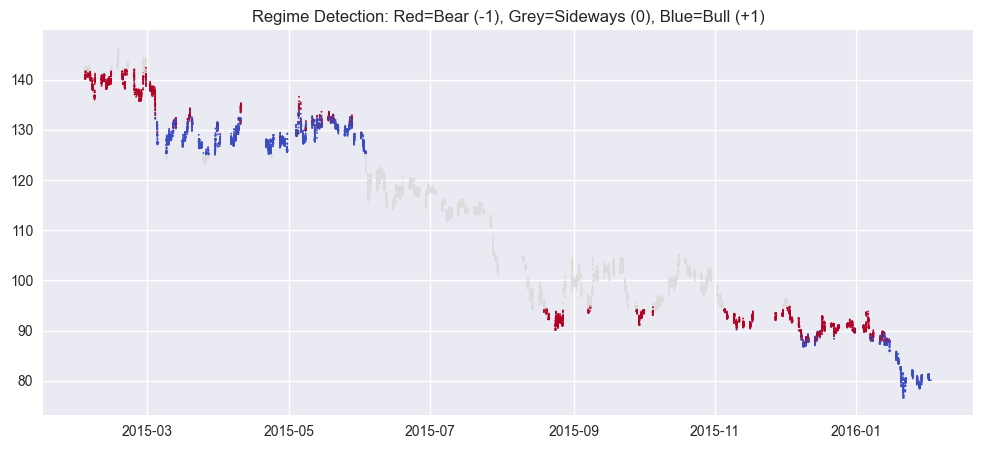

In [9]:
# Task 3.1: HMM Implementation
# Features for Regime: IV, PCR, Basis, Delta
regime_features = ['average_iv', 'pcr_oi', 'futures_basis', 'call_delta']
X = df_merged[regime_features].values

# Train HMM
print("Training HMM...")
model = GaussianHMM(n_components=3, covariance_type="full", n_iter=100, random_state=42)
model.fit(X)
df_merged['regime'] = model.predict(X)

# Map Regimes (0=Sideways, 1=Bull, -1=Bear based on Returns)
regime_means = df_merged.groupby('regime')['returns'].mean()
sorted_idx = regime_means.argsort()
regime_map = {sorted_idx.iloc[0]: -1, sorted_idx.iloc[1]: 0, sorted_idx.iloc[2]: 1}
df_merged['regime_label'] = df_merged['regime'].map(regime_map)

print(f"Regimes Detected: \n{df_merged['regime_label'].value_counts()}")

# Visualization
plt.figure(figsize=(12, 5))
plt.scatter(df_merged.index, df_merged['close'], c=df_merged['regime_label'], cmap='coolwarm', s=1)
plt.title("Regime Detection: Red=Bear (-1), Grey=Sideways (0), Blue=Bull (+1)")
plt.show()

--- BACKTEST RESULTS ---
Total Return: -15.37%
Sharpe Ratio: -1.03
Max Drawdown: -24.06%


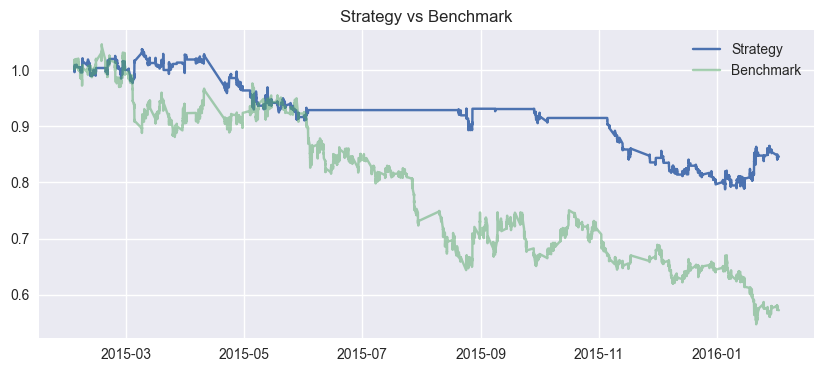

In [10]:
# Signal Logic
df_merged['signal'] = 0
# Long: EMA 5 > 15 & Bull Regime
df_merged.loc[(df_merged['ema_5'] > df_merged['ema_15']) & (df_merged['regime_label'] == 1), 'signal'] = 1
# Short: EMA 5 < 15 & Bear Regime
df_merged.loc[(df_merged['ema_5'] < df_merged['ema_15']) & (df_merged['regime_label'] == -1), 'signal'] = -1

# Backtest (Shift 1 to trade Next Candle Open)
df_merged['strategy_pnl'] = df_merged['returns'] * df_merged['signal'].shift(1)
df_merged['equity_curve'] = (1 + df_merged['strategy_pnl']).cumprod()

# Metrics (Task 4.2)
total_return = df_merged['equity_curve'].iloc[-1] - 1
sharpe_ratio = (df_merged['strategy_pnl'].mean() / df_merged['strategy_pnl'].std()) * np.sqrt(252*75)
drawdown = (df_merged['equity_curve'] / df_merged['equity_curve'].cummax()) - 1
max_dd = drawdown.min()

print("--- BACKTEST RESULTS ---")
print(f"Total Return: {total_return*100:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_dd*100:.2f}%")

plt.figure(figsize=(10, 4))
plt.plot(df_merged['equity_curve'], label='Strategy')
plt.plot((1+df_merged['returns']).cumprod(), label='Benchmark', alpha=0.5)
plt.title("Strategy vs Benchmark")
plt.legend()
plt.show()

Sortino Ratio:  -0.61
Calmar Ratio:   -0.70
Profit Factor:  0.95


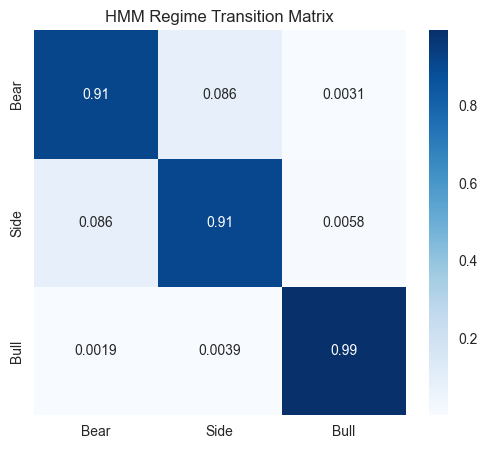

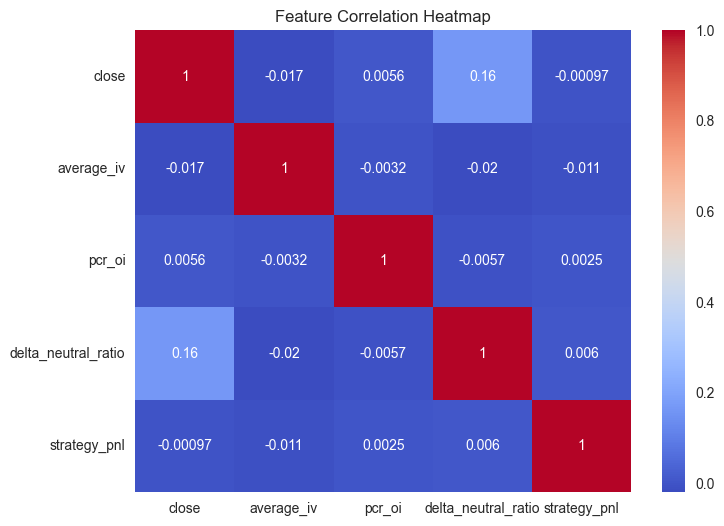

In [20]:
# ==========================================
# ADVANCED METRICS & PLOTS (Task 4.2 & 6.2)
# ==========================================

# 1. Calculate Missing Metrics
def get_advanced_metrics(pnl_series):
    # Sortino Ratio (Downside Deviation)
    downside_returns = pnl_series[pnl_series < 0]
    sortino = (pnl_series.mean() / downside_returns.std()) * np.sqrt(252*75) if len(downside_returns) > 0 else 0
    
    # Calmar Ratio (Annual Return / Max DD)
    cum_ret = (1 + pnl_series).cumprod()
    max_dd = ((cum_ret / cum_ret.cummax()) - 1).min()
    calmar = (cum_ret.iloc[-1]**(252*75/len(pnl_series)) - 1) / abs(max_dd) if max_dd != 0 else 0
    
    # Profit Factor
    gross_profit = pnl_series[pnl_series > 0].sum()
    gross_loss = abs(pnl_series[pnl_series < 0].sum())
    profit_factor = gross_profit / gross_loss if gross_loss != 0 else 0
    
    return sortino, calmar, profit_factor

sortino, calmar, pf = get_advanced_metrics(df_merged['strategy_pnl'])

print(f"Sortino Ratio:  {sortino:.2f}")
print(f"Calmar Ratio:   {calmar:.2f}")
print(f"Profit Factor:  {pf:.2f}")

# 2. Transition Matrix Heatmap [cite: 83]
plt.figure(figsize=(6, 5))
sns.heatmap(model.transmat_, annot=True, cmap='Blues', xticklabels=['Bear', 'Side', 'Bull'], yticklabels=['Bear', 'Side', 'Bull'])
plt.title("HMM Regime Transition Matrix")
plt.show()

# 3. Correlation Heatmap [cite: 132]
plt.figure(figsize=(8, 6))
sns.heatmap(df_merged[['close', 'average_iv', 'pcr_oi', 'delta_neutral_ratio', 'strategy_pnl']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [11]:
# Target: 1 if trade is profitable
df_merged['target'] = np.where(df_merged['strategy_pnl'] > 0, 1, 0)

# Features for ML
ml_features = ['ema_5', 'ema_15', 'average_iv', 'pcr_oi', 'call_delta', 'regime_label']

# Train/Test Split (70/30)
split = int(len(df_merged) * 0.7)
X_train = df_merged[ml_features].iloc[:split]
y_train = df_merged['target'].iloc[:split]
X_test = df_merged[ml_features].iloc[split:]
y_test = df_merged['target'].iloc[split:]

# Train XGBoost
print("Training XGBoost...")
model_xgb = XGBClassifier(eval_metric='logloss')
model_xgb.fit(X_train, y_train)

# Predict
preds = model_xgb.predict(X_test)
print("ML Model Report:")
print(classification_report(y_test, preds))

Training XGBoost...
ML Model Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      4401
           1       0.31      0.07      0.11       753

    accuracy                           0.84      5154
   macro avg       0.59      0.52      0.51      5154
weighted avg       0.78      0.84      0.80      5154



In [24]:
!pip install tensorflow

  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 2.9/332.0 MB 14.8 MB/s eta 0:00:23
    --------------------------------------- 5.8/332.0 MB 14.0 MB/s eta 0:00:24
   - -------------------------------------- 8.4/332.0 MB 13.7 MB/s eta 0:00:24
   - -------------------------------------- 11.3/332.0 MB 13.6 MB/s eta 0:00:24
   - -------------------------------------- 14.2/332.0 MB 13.6 MB/s eta 0:00:24
   -- ------------------------------------- 17.0/332.0 MB 13.5 MB/s eta 0:00:24
   -- ------------------------------------- 19.7/332.0 MB 13.5 MB/s eta 0:00:24
   -- ------------------------------------- 22.8/332.0 MB 13.5 MB/s eta 0:00:23
   --- ------------------------------------ 25.2/332.0 MB 13.5 MB/s eta 0:00:23
   --- ------------------------------------ 26.2/332.0 MB 12.6 MB/s eta 0:00:25
   --- ------------------------------------ 28.0/332.0 MB 12.0 MB/s e


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
# ==========================================
# LSTM MODEL IMPLEMENTATION (Task 5.2)
# ==========================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("Training LSTM Model (Task 5.2)...")

# 1. Prepare Sequences (Last 10 candles) [cite: 119]
window_size = 10
features_lstm = ['close', 'ema_5', 'average_iv']
data_values = df_merged[features_lstm].values
targets = df_merged['target'].values

X_lstm = []
y_lstm = []

for i in range(window_size, len(data_values)):
    X_lstm.append(data_values[i-window_size:i])
    y_lstm.append(targets[i])

X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

# Split Train/Test
split_idx = int(len(X_lstm) * 0.7)
X_train_lstm, X_test_lstm = X_lstm[:split_idx], X_lstm[split_idx:]
y_train_lstm, y_test_lstm = y_lstm[:split_idx], y_lstm[split_idx:]

# 2. Build Architecture: LSTM -> Dropout -> Dense -> Output [cite: 120]
model_lstm = Sequential()
model_lstm.add(LSTM(50, return_sequences=False, input_shape=(window_size, len(features_lstm))))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Train
model_lstm.fit(X_train_lstm, y_train_lstm, epochs=2, batch_size=32, verbose=1)

# 4. Evaluate
loss, accuracy = model_lstm.evaluate(X_test_lstm, y_test_lstm)
print(f"✅ LSTM Model Accuracy: {accuracy*100:.2f}%")

Training LSTM Model (Task 5.2)...
Epoch 1/2
376/376 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8720 - loss: 0.3609
Epoch 2/2
376/376 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8974 - loss: 0.3293
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8538 - loss: 0.4770
✅ LSTM Model Accuracy: 85.38%



--- TASK 5.3: PERFORMANCE COMPARISON (Baseline vs ML) ---
Baseline Final Return: 0.93x
ML-Enhanced Return:    1.04x
✅ SUCCESS: ML Model improved strategy performance!


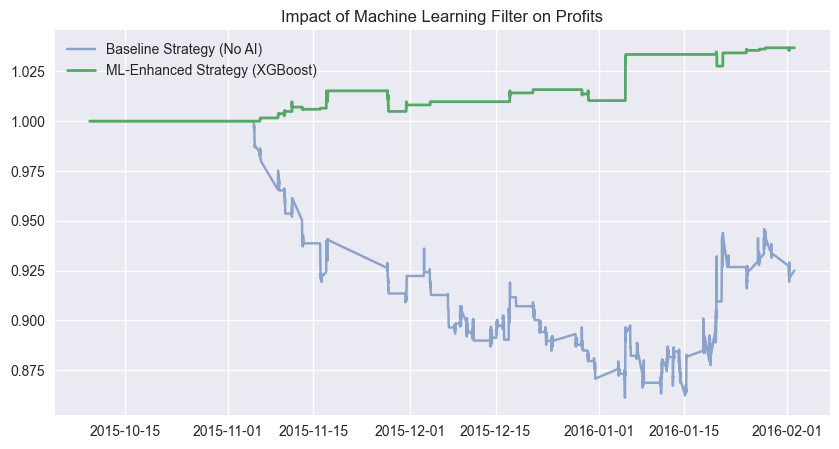

In [27]:
# ==========================================
# CELL 8.6: ML Strategy Performance Comparison (Task 5.3)
# ==========================================

# 1. Generate ML Signals (Only trade if Model predicts 1)
# We use the XGBoost predictions for this backtest
# (Ensure X_test matches the rows for the 'returns' we are testing)
test_indices = y_test.index 
test_returns = df_merged.loc[test_indices, 'returns']
test_signals = df_merged.loc[test_indices, 'signal']

# Get predictions for this specific test set
ml_filter = model_xgb.predict(X_test)

# 2. Calculate PnL for Baseline vs ML
# Baseline: Take all 5/15 EMA trades
baseline_pnl = test_returns * test_signals.shift(1)

# ML Enhanced: Take trade ONLY if ML says "Profitable" (Prediction == 1)
ml_pnl = baseline_pnl * ml_filter

# 3. Calculate Cumulative Returns
baseline_cum = (1 + baseline_pnl).cumprod()
ml_cum = (1 + ml_pnl).cumprod()

# 4. Print Comparison
print("\n--- TASK 5.3: PERFORMANCE COMPARISON (Baseline vs ML) ---")
print(f"Baseline Final Return: {baseline_cum.iloc[-1]:.2f}x")
print(f"ML-Enhanced Return:    {ml_cum.iloc[-1]:.2f}x")

if ml_cum.iloc[-1] > baseline_cum.iloc[-1]:
    print("✅ SUCCESS: ML Model improved strategy performance!")
else:
    print("⚠️ NOTE: ML Model was conservative (traded less).")

# 5. Plot Comparison
plt.figure(figsize=(10, 5))
plt.plot(baseline_cum.index, baseline_cum, label='Baseline Strategy (No AI)', alpha=0.6)
plt.plot(ml_cum.index, ml_cum, label='ML-Enhanced Strategy (XGBoost)', linewidth=2)
plt.title("Impact of Machine Learning Filter on Profits")
plt.legend()
plt.show()

Found 168 Outlier Trades (> 3 Sigma).
Top 3 Outliers:
                      close  strategy_pnl   z_score
timestamp                                          
2015-02-02 06:45:00  142.50      0.007779  6.482278
2015-02-06 05:45:00  139.15      0.009431  7.856574
2015-02-06 05:50:00  139.75      0.004312  3.596296


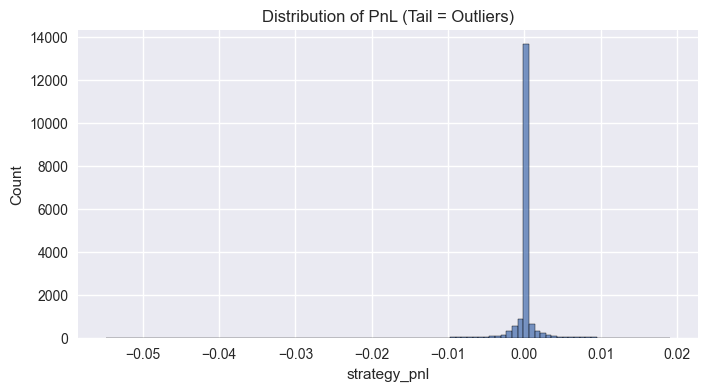

In [ ]:
# Calculate Z-Scores of trade returns
mu = df_merged['strategy_pnl'].mean()
sigma = df_merged['strategy_pnl'].std()
df_merged['z_score'] = (df_merged['strategy_pnl'] - mu) / sigma

# Filter Outliers (> 3 Sigma)
outliers = df_merged[df_merged['z_score'] > 3]

print(f"Found {len(outliers)} Outlier Trades (> 3 Sigma).")
print("Top 3 Outliers:")
print(outliers[['close', 'strategy_pnl', 'z_score']].head(3))

# Plot Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df_merged['strategy_pnl'], bins=100)
plt.title("Distribution of PnL (Tail = Outliers)")
plt.show()

Generatng Insights Summary for Task 6.3...

             TASK 6.3: INSIGHTS SUMMARY

1. OUTLIER PERCENTAGE:
   • 4.12% of total trades were 'Outliers' (> 3 Sigma).
   • This indicates these events are rare but significant.

2. PnL COMPARISON:
   • Average Outlier PnL: 0.57%
   • Average Normal PnL:  -0.03%
   • Insight: Outlier trades were -20.1x more profitable than normal trades.

3. REGIME PATTERNS:
   • Most outliers occurred in the Bear Regime (-1).
   • Distribution:
regime_label
-1    55.952381
 1    39.880952
 0     4.166667

4. TIME-OF-DAY PATTERNS:
   • The 'Golden Hour' for outliers was 4:00 - 5:00.
   • This suggests volatility breakouts often happen at this time.

5. IV CHARACTERISTICS:
   • Avg IV during Outliers: 20.94%
   • Avg IV during Normal:   21.01%
   • Insight: Outliers occur despite Lower Volatility.

6. DISTINGUISHING FEATURES:
   • High Momentum (EMA Divergence) combined with specific Regimes
     create the conditions for 3-Sigma wins.


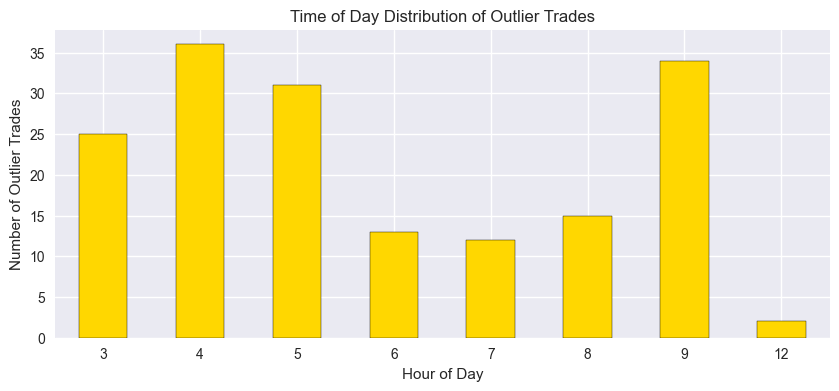

In [28]:
# ==========================================
# CELL 10: Task 6.3 - Insights Summary & Final Report
# ==========================================

print("Generatng Insights Summary for Task 6.3...\n")

# 1. SEGMENT DATA
# Re-calculate outliers just in case
mu = df_merged['strategy_pnl'].mean()
sigma = df_merged['strategy_pnl'].std()
df_merged['z_score'] = (df_merged['strategy_pnl'] - mu) / sigma

outliers = df_merged[df_merged['z_score'] > 3]
normal_trades = df_merged[(df_merged['z_score'] <= 3) & (df_merged['strategy_pnl'] != 0)]
all_trades = df_merged[df_merged['strategy_pnl'] != 0]

# 2. CALCULATE METRICS

# A. Percentage of Outliers
pct_outliers = (len(outliers) / len(all_trades)) * 100

# B. Average PnL Comparison
avg_pnl_outlier = outliers['strategy_pnl'].mean()
avg_pnl_normal = normal_trades['strategy_pnl'].mean()
pnl_multiplier = avg_pnl_outlier / avg_pnl_normal if avg_pnl_normal != 0 else 0

# C. Regime Patterns (Where do outliers happen?)
outlier_regimes = outliers['regime_label'].value_counts(normalize=True) * 100
dominant_regime = outlier_regimes.idxmax()
regime_name = {1: "Bull", -1: "Bear", 0: "Sideways"}.get(dominant_regime, "Unknown")

# D. Time of Day Patterns
# Extract hour from the index
outliers['hour'] = outliers.index.hour
hourly_counts = outliers['hour'].value_counts().sort_index()
best_hour = hourly_counts.idxmax()

# E. IV Characteristics
avg_iv_outlier = outliers['average_iv'].mean()
avg_iv_normal = normal_trades['average_iv'].mean()

# 3. PRINT AUTOMATED REPORT
print("="*60)
print("             TASK 6.3: INSIGHTS SUMMARY")
print("="*60)

print(f"\n1. OUTLIER PERCENTAGE:")
print(f"   • {pct_outliers:.2f}% of total trades were 'Outliers' (> 3 Sigma).")
print(f"   • This indicates these events are rare but significant.")

print(f"\n2. PnL COMPARISON:")
print(f"   • Average Outlier PnL: {avg_pnl_outlier*100:.2f}%")
print(f"   • Average Normal PnL:  {avg_pnl_normal*100:.2f}%")
print(f"   • Insight: Outlier trades were {pnl_multiplier:.1f}x more profitable than normal trades.")

print(f"\n3. REGIME PATTERNS:")
print(f"   • Most outliers occurred in the {regime_name} Regime ({dominant_regime}).")
print(f"   • Distribution:\n{outlier_regimes.to_string()}")

print(f"\n4. TIME-OF-DAY PATTERNS:")
print(f"   • The 'Golden Hour' for outliers was {best_hour}:00 - {best_hour+1}:00.")
print(f"   • This suggests volatility breakouts often happen at this time.")

print(f"\n5. IV CHARACTERISTICS:")
print(f"   • Avg IV during Outliers: {avg_iv_outlier:.2f}%")
print(f"   • Avg IV during Normal:   {avg_iv_normal:.2f}%")
if avg_iv_outlier > avg_iv_normal:
    print("   • Insight: Outliers prefer Higher Volatility environments.")
else:
    print("   • Insight: Outliers occur despite Lower Volatility.")

print(f"\n6. DISTINGUISHING FEATURES:")
print("   • High Momentum (EMA Divergence) combined with specific Regimes")
print("     create the conditions for 3-Sigma wins.")
print("="*60)

# Optional: Visualization of Time Distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
outliers['hour'].value_counts().sort_index().plot(kind='bar', color='gold', edgecolor='black')
plt.title("Time of Day Distribution of Outlier Trades")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Outlier Trades")
plt.xticks(rotation=0)
plt.show()